###  Plot Camera-Level Jaccard Similarity Map

This map shows each camera-trap array as a small circle, colored by array-level Jaccard similarity.

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [9]:


OUTPUT_PATH = "../../outputs"
DATA_PATH = "../../data"
# camera-level comparison file
CAMERA_COMPARE_FILE = f"{OUTPUT_PATH}/camera_level_ssusa_iucn_comparison.pkl"

# Load comparison results
camera_compare = pd.read_pickle(CAMERA_COMPARE_FILE)

print("Shape:", camera_compare.shape)
camera_compare.head()

Shape: (7323, 21)


,camera_fp_id,Habitat,Development_Level,Feature_Type,Camera_Trap_Array,Longitude,Latitude,unique_nights,obs_species,S_obs,...,S_pred,overlap_species,missing_species,additional_species,union_species,overlap_n,missing_n,additional_n,union_n,jaccard_index
0,-100.23311000_35.92725000,Grassland,Wild,Water source,{GeneHowe},-100.233110,35.927250,18,"{procyon lotor, odocoileus virginianus}",2,...,18,"{procyon lotor, odocoileus virginianus}","{lynx rufus, sciurus niger, sylvilagus florida...",{},"{lynx rufus, sciurus niger, sylvilagus florida...",2,16,0,18,0.111111
1,-100.24179000_35.92768000,Grassland,Wild,Water source,{GeneHowe},-100.241790,35.927680,20,"{procyon lotor, odocoileus virginianus}",2,...,18,"{procyon lotor, odocoileus virginianus}","{lynx rufus, sciurus niger, sylvilagus florida...",{},"{lynx rufus, sciurus niger, sylvilagus florida...",2,16,0,18,0.111111
2,-100.24180200_35.92767900,Grassland,Wild,Water source,{GeneHowe},-100.241802,35.927679,49,"{procyon lotor, canis latrans, odocoileus hemi...",4,...,18,"{procyon lotor, canis latrans, odocoileus hemi...","{lynx rufus, sylvilagus floridanus, sciurus ni...",{},"{lynx rufus, sciurus niger, sylvilagus florida...",4,14,0,18,0.222222
3,-100.24181000_35.92775000,Grassland,Wild,Water source,{GeneHowe},-100.241810,35.927750,36,{odocoileus virginianus},1,...,18,{odocoileus virginianus},"{lynx rufus, sciurus niger, sylvilagus florida...",{},"{lynx rufus, sciurus niger, sylvilagus florida...",1,17,0,18,0.055556
4,-100.24212710_35.92756100,Grassland,Wild,Trail game,{GeneHowe},-100.242127,35.927561,4,{odocoileus virginianus},1,...,18,{odocoileus virginianus},"{lynx rufus, sciurus niger, sylvilagus florida...",{},"{lynx rufus, sciurus niger, sylvilagus florida...",1,17,0,18,0.055556


In [10]:
camera_compare.columns

Index(['camera_fp_id', 'Habitat', 'Development_Level', 'Feature_Type',
       'Camera_Trap_Array', 'Longitude', 'Latitude', 'unique_nights',
       'obs_species', 'S_obs', 'pred_species', 'S_pred', 'overlap_species',
       'missing_species', 'additional_species', 'union_species', 'overlap_n',
       'missing_n', 'additional_n', 'union_n', 'jaccard_index'],
      dtype='object')

### Load countries geodata and extract USA 

In [11]:
# Natural Earth country boundaries

COUNTRIES_FILE = (
    DATA_PATH +
    "/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
)

countries = gpd.read_file(COUNTRIES_FILE)

print("CRS:", countries.crs)
print("Countries:", len(countries))

countries.head()

CRS: EPSG:4326
Countries: 177


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [12]:
usa = countries[
    countries["ADMIN"] == "United States of America"
].copy()

print("USA polygons:", len(usa))

usa[["ADMIN"]]

USA polygons: 1


,ADMIN
4,United States of America


### Create camera point GeoDataFrame from longitude/latitude

In [13]:
camera_points_wgs = gpd.GeoDataFrame(
    camera_compare.copy(),
    geometry=gpd.points_from_xy(
        camera_compare["Longitude"],
        camera_compare["Latitude"]
    ),
    crs="EPSG:4326"
)


### Split mainland and Alaska cameras

In [14]:
mainland_cameras = camera_points_wgs[
    (camera_points_wgs["Longitude"] >= -125) &
    (camera_points_wgs["Longitude"] <= -66) &
    (camera_points_wgs["Latitude"] >= 24) &
    (camera_points_wgs["Latitude"] <= 50)
].copy()

alaska_cameras = camera_points_wgs[
    (camera_points_wgs["Longitude"] >= -170) &
    (camera_points_wgs["Longitude"] <= -130) &
    (camera_points_wgs["Latitude"] >= 50) &
    (camera_points_wgs["Latitude"] <= 72)
].copy()

### Plot the map

In [15]:
# Custom red → orange → green colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_jaccard",
    ["#7F0000", "#D7301F", "#F16913", "#31A354", "#006D2C"]
)


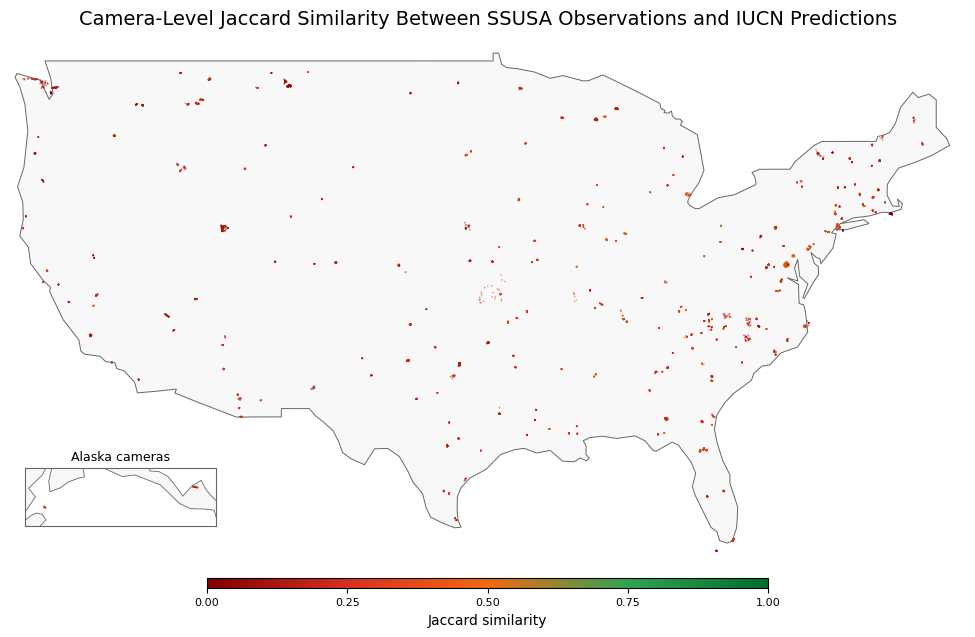

In [22]:
fig, ax = plt.subplots(figsize=(13, 8))

vmin, vmax = 0, 1

# U.S. background from your Natural Earth file
usa.plot(
    ax=ax,
    color="#f8f8f8",
    edgecolor="#666666",
    linewidth=0.7,
    zorder=1
)

# Mainland camera points
mainland_cameras.plot(
    ax=ax,
    column="jaccard_index",
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    markersize=1.5,
    alpha=0.5,
    edgecolor="none",
    legend=False,
    zorder=2
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    "Camera-Level Jaccard Similarity Between SSUSA Observations and IUCN Predictions",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

# Alaska inset
ax_ak = inset_axes(
    ax,
    width="20%",
    height="20%",
    loc="lower left",
    borderpad=1.1
)

usa.plot(
    ax=ax_ak,
    color="#f8f8f8",
    edgecolor="#666666",
    linewidth=0.6,
    zorder=1
)

alaska_cameras.plot(
    ax=ax_ak,
    column="jaccard_index",
    cmap=custom_cmap,
    vmin=vmin,
    vmax=vmax,
    markersize=1.5,
    alpha=0.5,
    edgecolor="none",
    legend=False,
    zorder=2
)

if len(alaska_cameras) > 0:
    ax_ak.set_xlim(alaska_cameras["Longitude"].min() - 2, alaska_cameras["Longitude"].max() + 2)
    ax_ak.set_ylim(alaska_cameras["Latitude"].min() - 1, alaska_cameras["Latitude"].max() + 1)

ax_ak.set_title("Alaska cameras", fontsize=9)
ax_ak.set_xticks([])
ax_ak.set_yticks([])

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("#666666")

# Thin horizontal colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.2,
    pad=0.02,
    shrink=0.45,
    aspect=60
)

cbar.set_label("Jaccard similarity", fontsize=10)
cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.ax.tick_params(labelsize=8)

plt.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.08)
plt.show()

In [18]:
print("Total camera locations:", len(camera_points_wgs))
print("Mainland cameras:", len(mainland_cameras))
print("Alaska cameras:", len(alaska_cameras))
print("Total plotted:", len(mainland_cameras) + len(alaska_cameras))

Total camera locations: 7323
Mainland cameras: 7246
Alaska cameras: 42
Total plotted: 7288
